In [4]:
import numpy as np 
import matplotlib.pyplot as plt
import pickle 
from centralized_solution import Cov, Cov2, solve,plot_me


**Part 1**


In [5]:
with open ('first_database.pkl','rb') as f:
    x,y=pickle.load(f)

C:\Users\BONETTI\AppData\Local\Temp\ipykernel_19680\1821999611.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  x,y=pickle.load(f)


Text(0.5, 1.0, 'Data points')

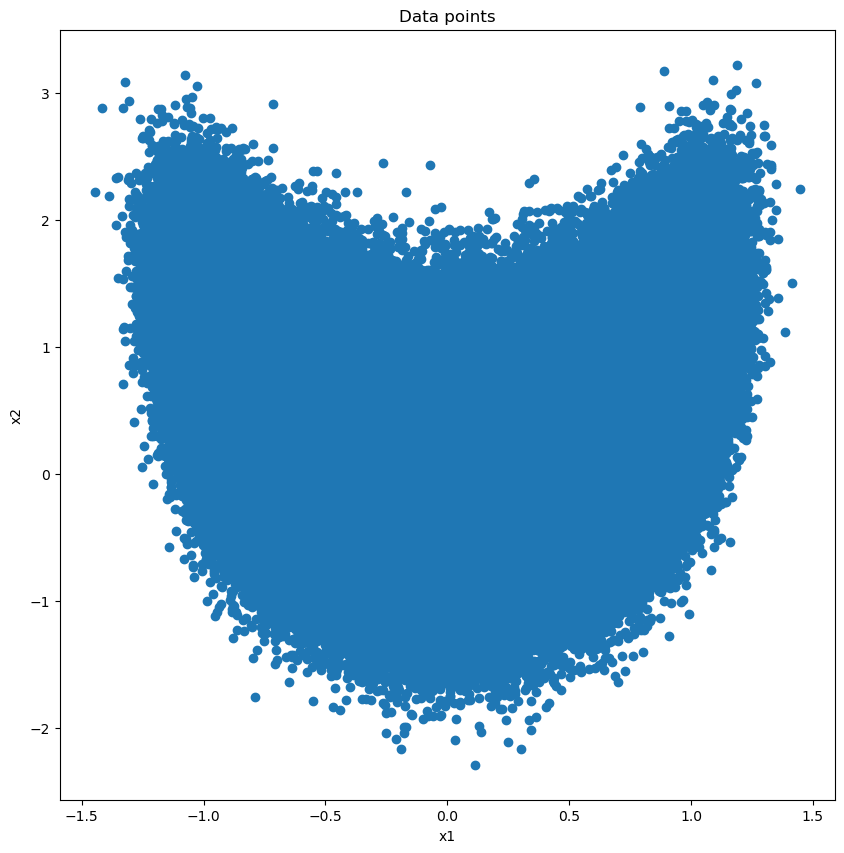

In [6]:
plt.figure(figsize=(10,10))
plt.scatter(x,y)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Data points')

Text(0.5, 1.0, 'Data points')

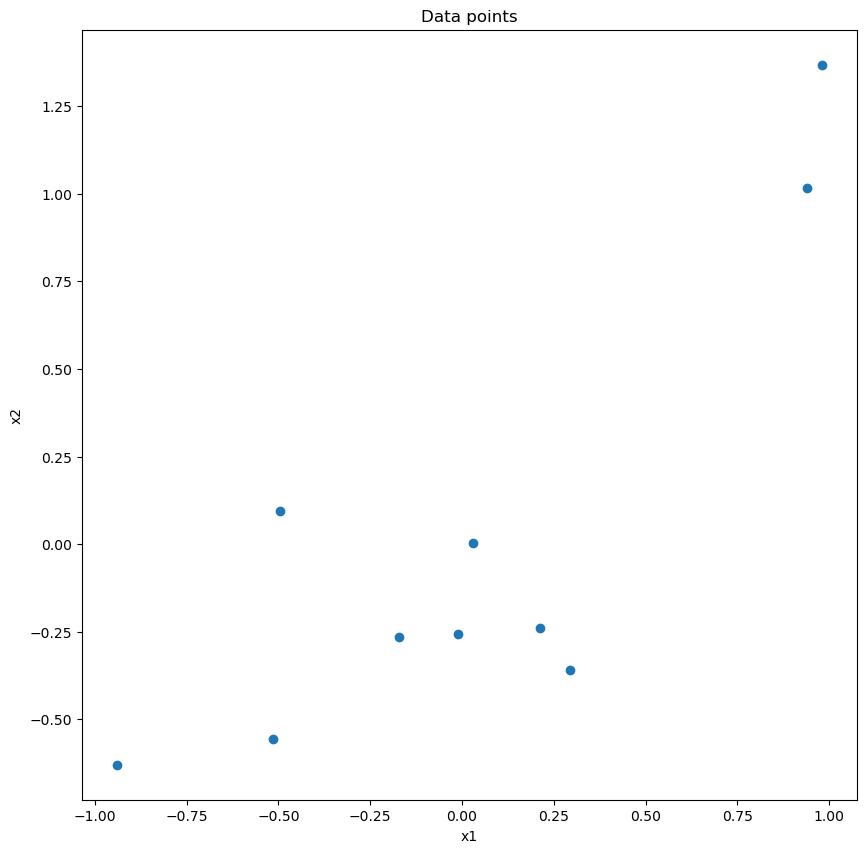

In [7]:
n=100
m=10
a=5 #agents 
sigma=0.5
sel = [i for i in range(n)]
ind = np.random.choice(sel, m, replace=False)
x_selected = [x[i] for i in ind]

y_selected = [y[i] for i in ind]
plt.figure(figsize=(10,10))
plt.scatter(x_selected,y_selected)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Data points')



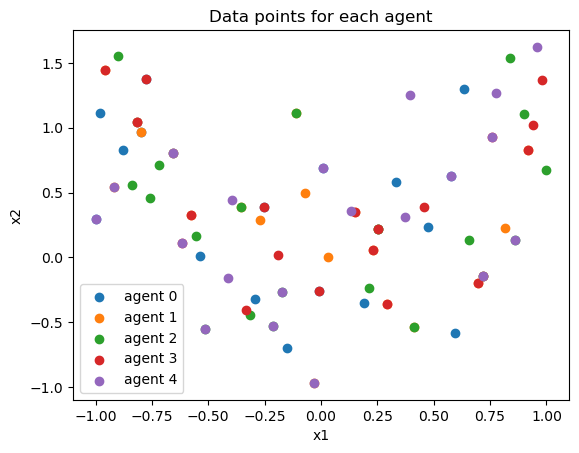

In [8]:
m=20

for agent in range(a):
    ind = np.random.choice(sel, m, replace=False)
    x_selected = [x[i] for i in ind]
    y_selected = [y[i] for i in ind]
    #plt.figure(figsize=(10,10))
    plt.scatter(x_selected,y_selected)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend([f'agent {i}' for i in range(a)])
    plt.title(f'Data points for each agent')
plt.show()

**decentralized gradient descent**


In [9]:
#on va appliquer avce ce premier graphe le decentralized gradient descent 
# Sélection des points 
n, m, a = 100, 20, 5


sigma = 0.5      # Bruit 
nu = 1.0         # Régularisation 
n_iter = 5000   # Nombre d'itérations

# 1. Chargement et préparation
with open('first_database.pkl', 'rb') as f:
    x_full, y_full = pickle.load(f)

x = x_full[:n]
y = y_full[:n]

sel = np.arange(n)
ind = np.random.choice(sel, m, replace=False)
x_m = x[ind]

# on charge les matrices Knm et Kmm 
Kmm=Cov(x_m)
Knm=Cov2(x,x_m)

# solution pour le kernel ridge est un alpha * 
a_star= (sigma**2)*Kmm + Knm.T @ Knm + nu*np.eye(m)
b_star=Knm.T@y
alpha_star=np.linalg.solve(a_star,b_star)


#construction de la matrice W 
# Exemple : Graphe en cycle (chaque agent parle à ses 2 voisins)
W = np.zeros((a, a))
for i in range(a):
    W[i, i] = 0.5
    W[i, (i-1)%a] = 0.25
    W[i, (i+1)%a] = 0.25
    

#garaphe 2 - line 
W2=np.zeros((a, a))
for i in range(a):
            W2[i, i] = 0.6
            if i > 0: W2[i, i-1] = 0.2
            if i < a-1: W2[i, i+1] = 0.2
        # Ajustement des bords pour la double stochasticité
W2[0, 0], W2[-1, -1] = 0.8, 0.8


#graphe complet 
W3 = np.ones((a, a)) / a

C:\Users\BONETTI\AppData\Local\Temp\ipykernel_19680\3717172870.py:12: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  x_full, y_full = pickle.load(f)


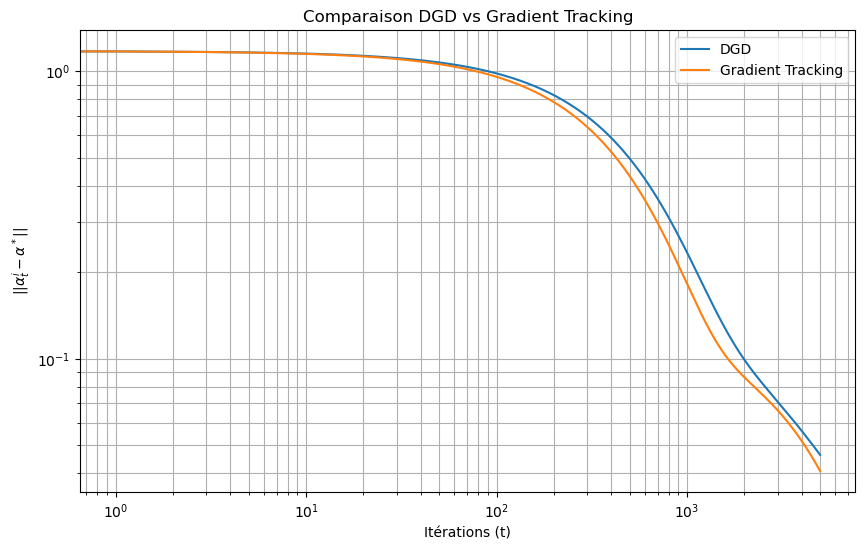

In [10]:
#on va débuter le DGD 
# 1. on initialise 
alpha_dgd = np.zeros((a,m)) # sequence des alpha necessaires pour le calcul 
alpha_gt=np.zeros((a,m))
g_gt=np.zeros((a,m)) #on voit dans la formule de gradient trackin la presence des gradeints pour chaque device 

# INITIALISATION
for i in range(a):
    idx_loc = range(i*20, (i+1)*20)
    Ki, yi = Knm[idx_loc, :], y[idx_loc]
    # Gradient à alpha = 0
    g_gt[i] = (sigma**2/a) * Kmm @ alpha_gt[i] + Ki.T @ (Ki @ alpha_gt[i] - yi) + (nu/a) * alpha_gt[i]



erreur_dgd=[]
erreur_gt=[]

#pas 
eta=0.001

for t in range (n_iter):
    
    #on fait les etapes pour DGD 
    new_alpha= np.zeros_like(alpha_dgd)
    for i in range (a): #pour chaque agent 
        idx_loc = range(i*20, (i+1)*20)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        grad_i= (sigma**2/a) * Kmm @ alpha_dgd[i] + Ki.T @ (Ki @ alpha_dgd[i] - yi) + (nu/a) * alpha_dgd[i]
        new_alpha[i] = W3[i, :] @ alpha_dgd - eta * grad_i
    alpha_dgd= new_alpha
    erreur_dgd.append(np.linalg.norm(np.mean(alpha_dgd, axis=0) - alpha_star))

    
    
    #on fait pour GT 
    new_alpha_2= np.zeros_like(alpha_gt)
    #comme vu dans le poly, on a aussi les g pour chaque device 
    new_g=np.zeros_like(g_gt)
    for i in range (a): #pour chaque agent 
        idx_loc = range(i*20, (i+1)*20)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        grad_k= (sigma**2/a) * Kmm @ alpha_gt[i] + Ki.T @ (Ki @ alpha_gt[i] - yi) + (nu/a) * alpha_gt[i]
        # mise à jour alpha
        new_alpha_2[i] = W3[i, :] @ alpha_gt - eta * g_gt[i]
        #on a deux gardeints dans la formule 
        #gard_k est le courant 
        #grad_k1 est le prochain 
        grad_k1= (sigma**2/a) * Kmm @ new_alpha_2[i] + Ki.T @ (Ki @ new_alpha_2[i] - yi) + (nu/a) * new_alpha_2[i]
        
        new_g[i]= W3[i, :] @ g_gt - grad_k + grad_k1
    alpha_gt=new_alpha_2
    g_gt=new_g
    erreur_gt.append(np.linalg.norm(np.mean(alpha_gt, axis=0) - alpha_star))
    
    
plt.figure(figsize=(10, 6))
plt.loglog(erreur_dgd, label='DGD')
plt.loglog(erreur_gt, label='Gradient Tracking')
plt.xlabel('Itérations (t)')
plt.ylabel(r'$||\alpha_t^i - \alpha^*||$')
plt.title('Comparaison DGD vs Gradient Tracking')
plt.legend()
plt.grid(True, which="both", ls="-")   
        


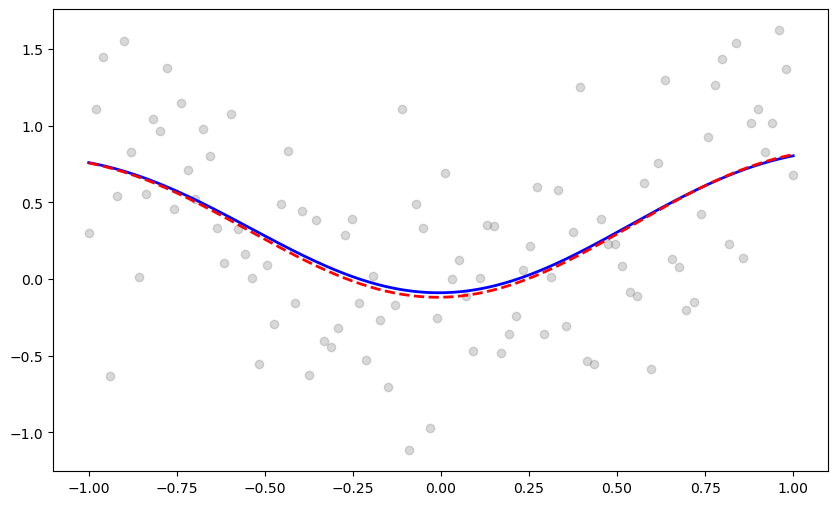

In [11]:
#visualisation de la fonction apprise 

nt = 250
x_prime = np.linspace(-1, 1, nt) # 
K_test = Cov2(x_prime, x_m) 

plt.figure(figsize=(10, 6))

#On affiche les données brutes
plt.scatter(x, y, alpha=0.3, label='Données bruitées', color='gray')

#On affiche la solution prédite par l'agent 0 pour DGD
y_pred_dgd = K_test @ alpha_dgd[0] 
plt.plot(x_prime, y_pred_dgd, label='Fonction apprise (DGD)', color='blue', linewidth=2)

#On affiche la solution prédite par l'agent 0 pour Gradient Tracking
y_pred_gt = K_test @ alpha_gt[0]
plt.plot(x_prime, y_pred_gt, '--', label='Fonction apprise (GT)', color='red', linewidth=2)

**communication dirigée**


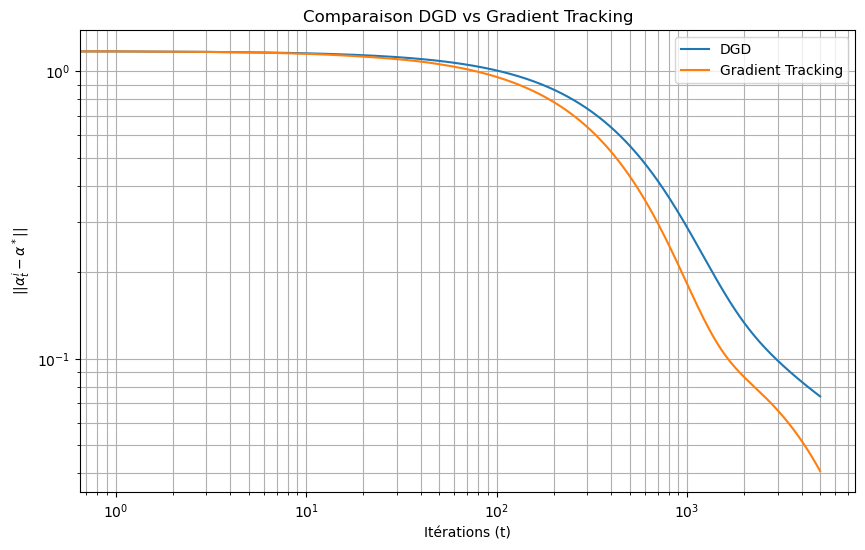

In [12]:
# matrice de communication dirigée 
W_directed = np.zeros((a, a))
for i in range(a):
    W_directed[i, i] = 0.7  # L'agent garde 70% de son information
    W_directed[i, (i-1)%a] = 0.3  # L'agent reçoit 30% de son voisin de gauche uniquement

#on va débuter le DGD 
# 1. on initialise 
alpha_dgd = np.zeros((a,m)) # sequence des alpha necessaires pour le calcul 
alpha_gt=np.zeros((a,m))
g_gt=np.zeros((a,m)) #on voit dans la formule de gradient trackin la presence des gradeints pour chaque device 

# INITIALISATION
for i in range(a):
    idx_loc = range(i*20, (i+1)*20)
    Ki, yi = Knm[idx_loc, :], y[idx_loc]
    # Gradient à alpha = 0
    g_gt[i] = (sigma**2/a) * Kmm @ alpha_gt[i] + Ki.T @ (Ki @ alpha_gt[i] - yi) + (nu/a) * alpha_gt[i]



erreur_dgd=[]
erreur_gt=[]

#pas 
eta=0.001

for t in range (n_iter):
    
    #on fait les etapes pour DGD 
    new_alpha= np.zeros_like(alpha_dgd)
    for i in range (a): #pour chaque agent 
        idx_loc = range(i*20, (i+1)*20)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        grad_i= (sigma**2/a) * Kmm @ alpha_dgd[i] + Ki.T @ (Ki @ alpha_dgd[i] - yi) + (nu/a) * alpha_dgd[i]
        new_alpha[i] = W_directed [i, :] @ alpha_dgd - eta * grad_i
    alpha_dgd= new_alpha
    erreur_dgd.append(np.linalg.norm(np.mean(alpha_dgd, axis=0) - alpha_star))

    
    
    #on fait pour GT 
    new_alpha_2= np.zeros_like(alpha_gt)
    #comme vu dans le poly, on a aussi les g pour chaque device 
    new_g=np.zeros_like(g_gt)
    for i in range (a): #pour chaque agent 
        idx_loc = range(i*20, (i+1)*20)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        grad_k= (sigma**2/a) * Kmm @ alpha_gt[i] + Ki.T @ (Ki @ alpha_gt[i] - yi) + (nu/a) * alpha_gt[i]
        # mise à jour alpha
        new_alpha_2[i] = W_directed [i, :] @ alpha_gt - eta * g_gt[i]
        #on a deux gardeints dans la formule 
        #gard_k est le courant 
        #grad_k1 est le prochain 
        grad_k1= (sigma**2/a) * Kmm @ new_alpha_2[i] + Ki.T @ (Ki @ new_alpha_2[i] - yi) + (nu/a) * new_alpha_2[i]
        
        new_g[i]= W_directed [i, :] @ g_gt - grad_k + grad_k1
    alpha_gt=new_alpha_2
    g_gt=new_g
    erreur_gt.append(np.linalg.norm(np.mean(alpha_gt, axis=0) - alpha_star))
    
    
plt.figure(figsize=(10, 6))
plt.loglog(erreur_dgd, label='DGD')
plt.loglog(erreur_gt, label='Gradient Tracking')
plt.xlabel('Itérations (t)')
plt.ylabel(r'$||\alpha_t^i - \alpha^*||$')
plt.title('Comparaison DGD vs Gradient Tracking')
plt.legend()
plt.grid(True, which="both", ls="-")   
        


**perte d'informations**

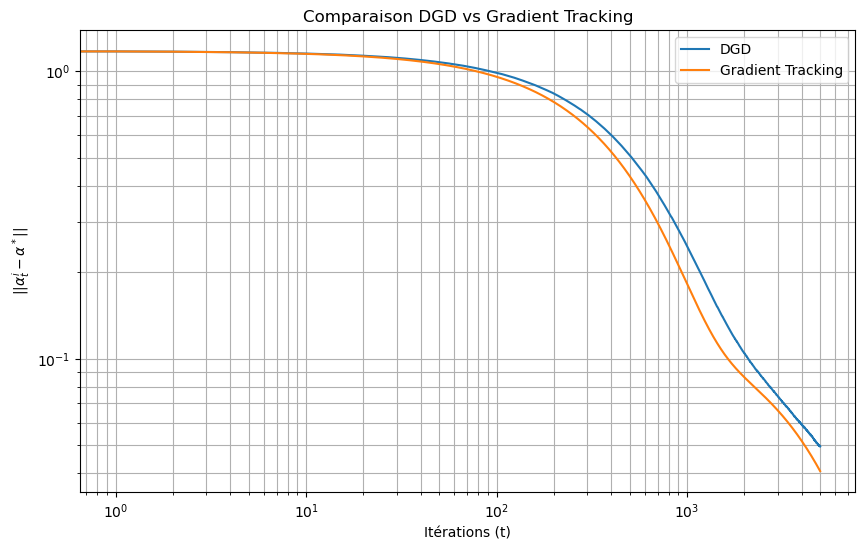

In [13]:
p_loss = 0.2  # Probabilité de perte de 20%

#on va débuter le DGD 
# 1. on initialise 
alpha_dgd = np.zeros((a,m)) # sequence des alpha necessaires pour le calcul 
alpha_gt=np.zeros((a,m))
g_gt=np.zeros((a,m)) #on voit dans la formule de gradient trackin la presence des gradeints pour chaque device 

# INITIALISATION
for i in range(a):
    idx_loc = range(i*20, (i+1)*20)
    Ki, yi = Knm[idx_loc, :], y[idx_loc]
    # Gradient à alpha = 0
    g_gt[i] = (sigma**2/a) * Kmm @ alpha_gt[i] + Ki.T @ (Ki @ alpha_gt[i] - yi) + (nu/a) * alpha_gt[i]



erreur_dgd=[]
erreur_gt=[]

#pas 
eta=0.001

for t in range (n_iter):
    
    # On décide si la communication réussit pour cette itération
    if np.random.rand() < p_loss:
        W_curr = np.eye(a)  # Perte totale : personne ne communique
    else:
        W_curr = W3         # Communication normale
        
        
    #on fait les etapes pour DGD 
    new_alpha= np.zeros_like(alpha_dgd)
    for i in range (a): #pour chaque agent 
        idx_loc = range(i*20, (i+1)*20)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        grad_i= (sigma**2/a) * Kmm @ alpha_dgd[i] + Ki.T @ (Ki @ alpha_dgd[i] - yi) + (nu/a) * alpha_dgd[i]
        new_alpha[i] = W_curr[i, :] @ alpha_dgd - eta * grad_i
    alpha_dgd= new_alpha
    erreur_dgd.append(np.linalg.norm(np.mean(alpha_dgd, axis=0) - alpha_star))

    
    
    #on fait pour GT 
    new_alpha_2= np.zeros_like(alpha_gt)
    #comme vu dans le poly, on a aussi les g pour chaque device 
    new_g=np.zeros_like(g_gt)
    for i in range (a): #pour chaque agent 
        idx_loc = range(i*20, (i+1)*20)
        Ki = Knm[idx_loc, :]
        yi = y[idx_loc]
        
        grad_k= (sigma**2/a) * Kmm @ alpha_gt[i] + Ki.T @ (Ki @ alpha_gt[i] - yi) + (nu/a) * alpha_gt[i]
        # mise à jour alpha
        new_alpha_2[i] = W_curr[i, :] @ alpha_gt - eta * g_gt[i]
        #on a deux gardeints dans la formule 
        #gard_k est le courant 
        #grad_k1 est le prochain 
        grad_k1= (sigma**2/a) * Kmm @ new_alpha_2[i] + Ki.T @ (Ki @ new_alpha_2[i] - yi) + (nu/a) * new_alpha_2[i]
        
        new_g[i]= W_curr[i, :] @ g_gt - grad_k + grad_k1
    alpha_gt=new_alpha_2
    g_gt=new_g
    erreur_gt.append(np.linalg.norm(np.mean(alpha_gt, axis=0) - alpha_star))
    
    
plt.figure(figsize=(10, 6))
plt.loglog(erreur_dgd, label='DGD')
plt.loglog(erreur_gt, label='Gradient Tracking')
plt.xlabel('Itérations (t)')
plt.ylabel(r'$||\alpha_t^i - \alpha^*||$')
plt.title('Comparaison DGD vs Gradient Tracking')
plt.legend()
plt.grid(True, which="both", ls="-")   
        


**asynchrone**

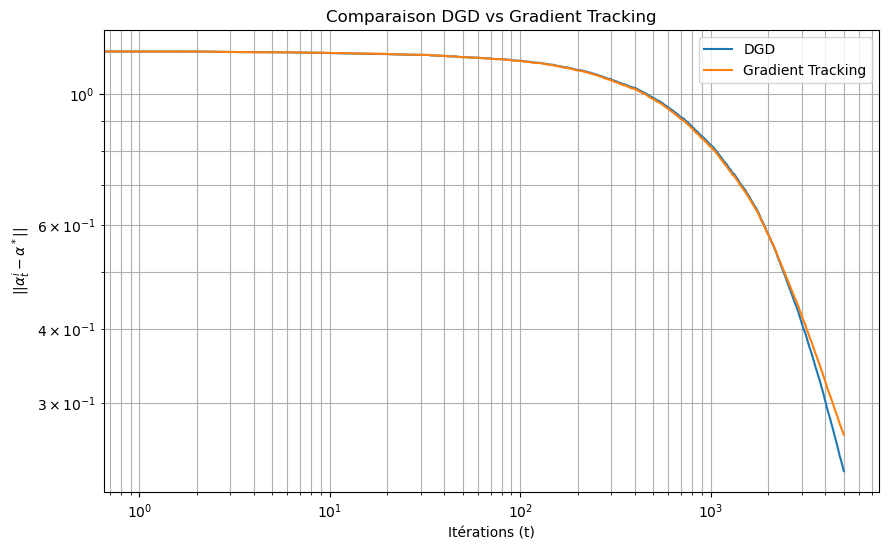

In [15]:

#on va débuter le DGD 
# 1. on initialise 
alpha_dgd = np.zeros((a,m)) # sequence des alpha necessaires pour le calcul 
alpha_gt=np.zeros((a,m))
g_gt=np.zeros((a,m)) #on voit dans la formule de gradient trackin la presence des gradeints pour chaque device 

# INITIALISATION
for i in range(a):
    idx_loc = range(i*20, (i+1)*20)
    Ki, yi = Knm[idx_loc, :], y[idx_loc]
    # Gradient à alpha = 0
    g_gt[i] = (sigma**2/a) * Kmm @ alpha_gt[i] + Ki.T @ (Ki @ alpha_gt[i] - yi) + (nu/a) * alpha_gt[i]



erreur_dgd=[]
erreur_gt=[]

#pas 
eta=0.001

for t in range (n_iter):
    
    # On choisit par exemple un seul agent au hasard qui va travailler
    agent_actif = np.random.randint(0, a)
    # On prépare les nouveaux conteneurs
    new_alpha = alpha_dgd.copy()
    new_alpha_2 = alpha_gt.copy()
    new_g = g_gt.copy()
    
    
    
    
    i = agent_actif
    idx_loc = range(i*20, (i+1)*20)
    Ki, yi = Knm[idx_loc, :], y[idx_loc]
        
    grad_i= (sigma**2/a) * Kmm @ alpha_dgd[i] + Ki.T @ (Ki @ alpha_dgd[i] - yi) + (nu/a) * alpha_dgd[i]
    new_alpha[i] = W3[i, :] @ alpha_dgd - eta * grad_i
    alpha_dgd= new_alpha
    erreur_dgd.append(np.linalg.norm(np.mean(alpha_dgd, axis=0) - alpha_star))

    
    
    
    
    
    grad_k= (sigma**2/a) * Kmm @ alpha_gt[i] + Ki.T @ (Ki @ alpha_gt[i] - yi) + (nu/a) * alpha_gt[i]
    # mise à jour alpha
    new_alpha_2[i] = W_curr[i, :] @ alpha_gt - eta * g_gt[i]
    #on a deux gardeints dans la formule 
    #gard_k est le courant 
    #grad_k1 est le prochain 
    grad_k1= (sigma**2/a) * Kmm @ new_alpha_2[i] + Ki.T @ (Ki @ new_alpha_2[i] - yi) + (nu/a) * new_alpha_2[i]
        
    new_g[i]= W_curr[i, :] @ g_gt - grad_k + grad_k1
    alpha_gt=new_alpha_2
    g_gt=new_g
    erreur_gt.append(np.linalg.norm(np.mean(alpha_gt, axis=0) - alpha_star))
    
    
plt.figure(figsize=(10, 6))
plt.loglog(erreur_dgd, label='DGD')
plt.loglog(erreur_gt, label='Gradient Tracking')
plt.xlabel('Itérations (t)')
plt.ylabel(r'$||\alpha_t^i - \alpha^*||$')
plt.title('Comparaison DGD vs Gradient Tracking')
plt.legend()
plt.grid(True, which="both", ls="-")   
        
